In [6]:
import pandas as pd
import os

seasons = {
    "2018-19": "data/season-1819_csv.csv",
    "2019-20": "data/season-1920_csv.csv",
    "2020-21": "data/season-2021_csv.csv",
    "2021-22": "data/season-2122_csv.csv",
    "2022-23": "data/season-2223_csv.csv",
}

dfs = []
for season, path in seasons.items():
    df = pd.read_csv(path)
    df["Season"] = season       
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f"Total matches loaded: {len(data)}")
print(f"Columns: {list(data.columns)}")
data.head()

Total matches loaded: 1900
Columns: ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA', 'Season', 'Time', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,10/08/2018,Man United,Leicester,2,1,H,1,0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,11/08/2018,Bournemouth,Cardiff,2,0,H,1,0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,11/08/2018,Fulham,Crystal Palace,0,2,A,0,1,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,11/08/2018,Huddersfield,Chelsea,0,3,A,0,2,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,11/08/2018,Newcastle,Tottenham,1,2,A,1,2,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
cols = ["Season", "Date", "HomeTeam", "AwayTeam",
        "FTHG", "FTAG", "FTR",      # full-time goals & result
        "HS", "AS",                  # shots
        "HST", "AST",                # shots on target
        "HC", "AC",                  # corners
        "HY", "AY", "HR", "AR"]     # yellow/red cards

df = data[cols].copy()

# Renaming for clarity
df.rename(columns={
    "FTHG": "HomeGoals", "FTAG": "AwayGoals", "FTR": "Result",
    "HS": "HomeShots", "AS": "AwayShots",
    "HST": "HomeShotsTarget", "AST": "AwayShotsTarget",
    "HC": "HomeCorners", "AC": "AwayCorners"
}, inplace=True)

# Drop rows with missing values
df.dropna(inplace=True)

print(df["Result"].value_counts())  

Result
H    844
A    635
D    421
Name: count, dtype: int64


C:\Users\rdnee\AppData\Local\Temp\ipykernel_12276\3233660794.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Result", palette=["#378ADD", "#E24B4A", "#639922"],


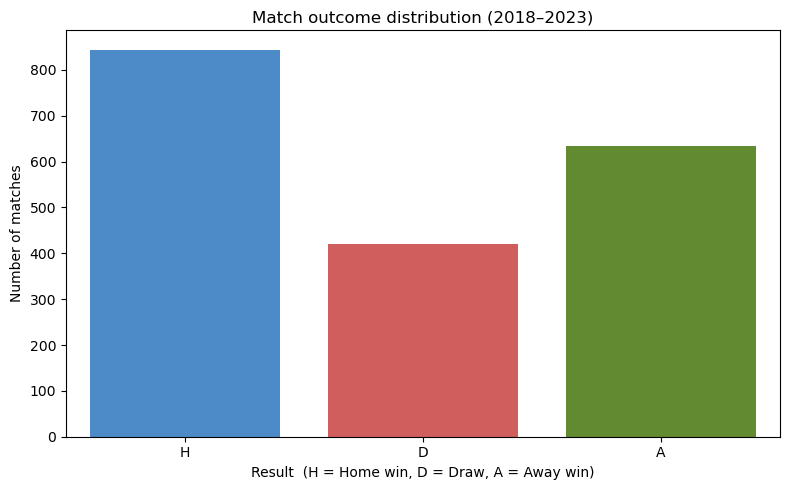

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Result distribution 
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Result", palette=["#378ADD", "#E24B4A", "#639922"],
              order=["H", "D", "A"])
plt.title("Match outcome distribution (2018–2023)")
plt.xlabel("Result  (H = Home win, D = Draw, A = Away win)")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.savefig("outputs/result_distribution.png", dpi=150)
plt.show()

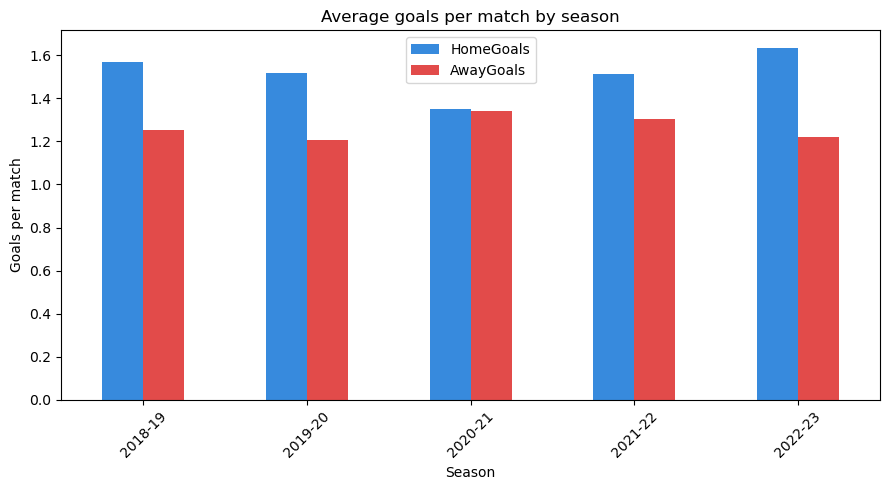

In [10]:
# Chart 2: Average goals per season 
goals_by_season = df.groupby("Season")[["HomeGoals", "AwayGoals"]].mean()

goals_by_season.plot(kind="bar", figsize=(9, 5), color=["#378ADD", "#E24B4A"])
plt.title("Average goals per match by season")
plt.ylabel("Goals per match")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/goals_by_season.png", dpi=150)
plt.show()

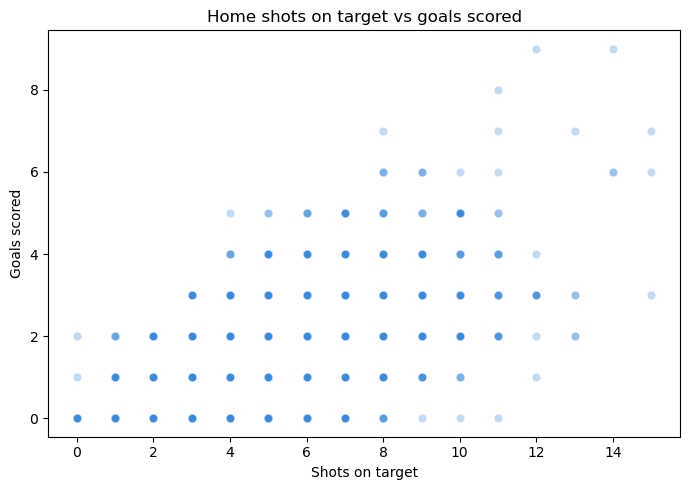

In [11]:
# Chart 3: Shots on target correlation 
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="HomeShotsTarget", y="HomeGoals", alpha=0.3, color="#378ADD")
plt.title("Home shots on target vs goals scored")
plt.xlabel("Shots on target")
plt.ylabel("Goals scored")
plt.tight_layout()
plt.savefig("outputs/shots_vs_goals.png", dpi=150)
plt.show()